* Name: Mohamed Mohy Mahmoud Akl
* ID: 120210268
* Lab: K-mean segmentation

Saving 42.jpg to 42.jpg
Processing image: 42.jpg


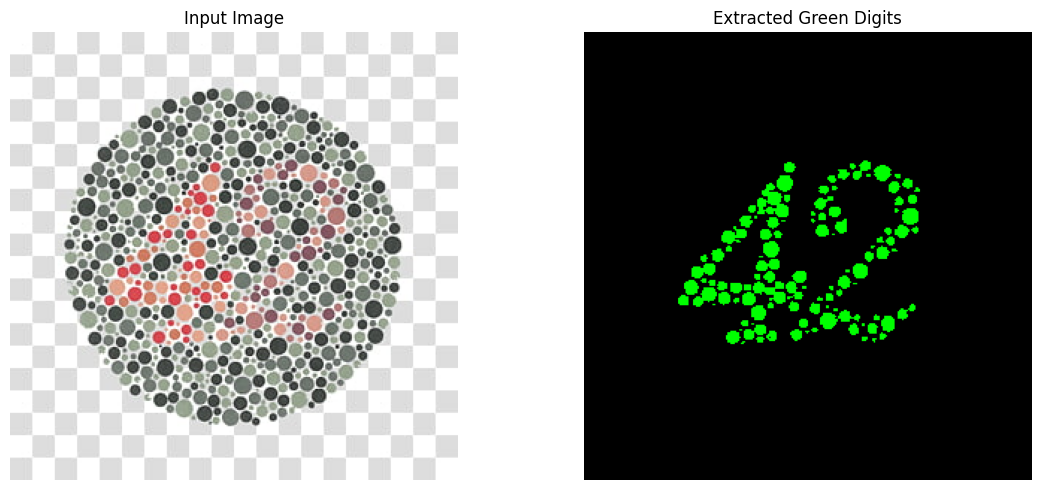

In [28]:
from google.colab import files
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# Step 1: Upload and store the image
uploaded = files.upload()
image_dir = 'SingleImageInput'
os.makedirs(image_dir, exist_ok=True)

for image_name in uploaded:
    with open(os.path.join(image_dir, image_name), 'wb') as f:
        f.write(uploaded[image_name])

# Step 2: K-Means clustering class
class CustomKMeans:
    def __init__(self, k=2, init_strategy='++', retries=5, max_iters=300, tol=1e-4, seed=None):
        self.k = k
        self.init_strategy = init_strategy
        self.retries = retries
        self.max_iters = max_iters
        self.tol = tol
        self.rng = np.random.RandomState(seed)
        self.centroids = None
        self.labels = None
        self.inertia = None
        self.iter_count = 0

    def _initialize_centers(self, data):
        n, d = data.shape
        centers = np.empty((self.k, d), dtype=data.dtype)
        centers[0] = data[self.rng.choice(n)]
        dist_sq = np.full(n, np.inf)
        for i in range(1, self.k):
            dist_sq = np.minimum(dist_sq, np.sum((data - centers[i-1])**2, axis=1))
            prob = dist_sq / dist_sq.sum()
            centers[i] = data[self.rng.choice(n, p=prob)]
        return centers

    def _lloyd_iteration(self, data, centers):
        for i in range(self.max_iters):
            dists = np.sum((data[:, None] - centers) ** 2, axis=2)
            new_labels = np.argmin(dists, axis=1)
            new_centers = np.empty_like(centers)
            for j in range(self.k):
                group = data[new_labels == j]
                new_centers[j] = group.mean(axis=0) if len(group) > 0 else data[self.rng.choice(len(data))]
            shift = np.sum((centers - new_centers)**2)
            if shift <= self.tol:
                break
            centers = new_centers
        final_dists = np.sum((data[:, None] - centers)**2, axis=2)
        final_labels = np.argmin(final_dists, axis=1)
        inertia_score = np.sum(final_dists[np.arange(len(final_dists)), final_labels])
        return centers, final_labels, inertia_score, i + 1

    def fit(self, data):
        best_score = np.inf
        for _ in range(self.retries):
            init_centers = self._initialize_centers(data) if self.init_strategy == '++' else data[self.rng.choice(len(data), self.k)]
            centers, labels, score, iters = self._lloyd_iteration(data, init_centers)
            if score < best_score:
                self.centroids = centers
                self.labels = labels
                self.inertia = score
                self.iter_count = iters
                best_score = score
        return self

    def predict(self, data):
        dists = np.sum((data[:, None] - self.centroids) ** 2, axis=2)
        return np.argmin(dists, axis=1)

# Step 3: Segment green digits from an image
def detect_green_digits(img_path):
    img = cv2.imread(img_path)
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab_img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    a_channel = lab_img[:, :, 1].astype(np.float64)
    a_channel = (a_channel - np.mean(a_channel)) / np.std(a_channel)
    flattened = a_channel.reshape(-1, 1)

    kmeans = CustomKMeans(k=2, init_strategy='++', retries=10, seed=101)
    kmeans.fit(flattened)
    clustered = kmeans.predict(flattened).reshape(a_channel.shape)
    green_label = np.argmax(kmeans.centroids)

    mask = np.zeros_like(rgb_img)
    mask[clustered == green_label] = [0, 255, 0]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask)
    plt.title("Extracted Green Digits")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Step 4: Run on the single uploaded image
single_file = next(iter(uploaded))
img_path = os.path.join(image_dir, single_file)
print(f"Processing image: {single_file}")
detect_green_digits(img_path)